In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_excel("FINALL_cleaned_student_stress.xlsx")

In [3]:
df.drop(columns=["timestamp"], inplace=True, errors='ignore')

In [4]:
X = df.drop("how_would_you_rate_your_current_stress_level?", axis=1)
y = df["how_would_you_rate_your_current_stress_level?"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [8]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.6470588235294118
              precision    recall  f1-score   support

           0       0.40      0.33      0.36         6
           1       0.67      0.80      0.73        15
           2       0.73      0.62      0.67        13

    accuracy                           0.65        34
   macro avg       0.60      0.58      0.59        34
weighted avg       0.64      0.65      0.64        34



In [11]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.33      0.33      0.33         6
           1       0.67      0.53      0.59        15
           2       0.44      0.54      0.48        13

    accuracy                           0.50        34
   macro avg       0.48      0.47      0.47        34
weighted avg       0.52      0.50      0.50        34



In [12]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.5588235294117647
              precision    recall  f1-score   support

           0       0.25      0.17      0.20         6
           1       0.52      0.80      0.63        15
           2       0.86      0.46      0.60        13

    accuracy                           0.56        34
   macro avg       0.54      0.48      0.48        34
weighted avg       0.60      0.56      0.54        34



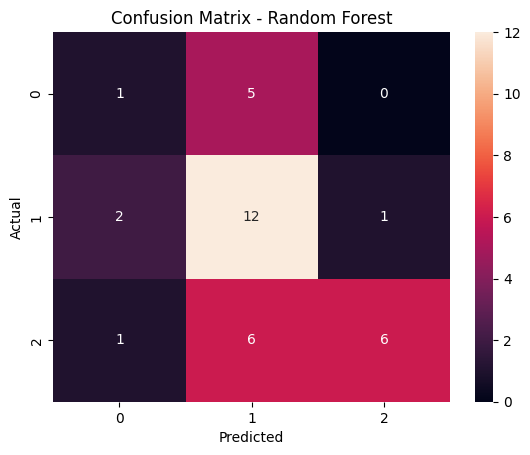

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
importances = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                         Feature  Importance
6        academic_pressure_level    0.274730
0                            age    0.166910
5       daily_social_media_usage    0.123981
7     physical_activity_per_week    0.110844
2                  year_of_study    0.104217
3  average_sleep_hours_per_night    0.088626
4    average_study_hours_per_day    0.071651
1                         gender    0.059040


In [15]:
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

           Model  Accuracy
0       Logistic  0.647059
1  Decision Tree  0.500000
2  Random Forest  0.558824


In [16]:
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
rf = RandomForestClassifier()

In [18]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
rf.feature_importances_

array([0.17188751, 0.07382387, 0.09222099, 0.09081048, 0.06805413,
       0.12164546, 0.28322754, 0.09833002])

In [20]:
import pandas as pd

importances = rf.feature_importances_

feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                         Feature  Importance
6        academic_pressure_level    0.283228
0                            age    0.171888
5       daily_social_media_usage    0.121645
7     physical_activity_per_week    0.098330
2                  year_of_study    0.092221
3  average_sleep_hours_per_night    0.090810
1                         gender    0.073824
4    average_study_hours_per_day    0.068054


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=5)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=10, n_estimators=200)


In [22]:
best_rf = grid.best_estimator_
best_rf.feature_importances_

array([0.16845617, 0.06175813, 0.1016976 , 0.0906609 , 0.07075646,
       0.12786433, 0.27323352, 0.10557289])

In [23]:
from sklearn.metrics import accuracy_score

acc_rf = accuracy_score(y_test, y_pred_rf)

In [24]:
acc_rf_tuned = accuracy_score(y_test, best_rf.predict(X_test))

In [25]:
print("Before tuning:", acc_rf)
print("After tuning:", acc_rf_tuned)

Before tuning: 0.5588235294117647
After tuning: 0.5294117647058824


In [26]:
for col in df.columns:
    print(col)

age
gender
year_of_study
average_sleep_hours_per_night
average_study_hours_per_day
daily_social_media_usage
academic_pressure_level
physical_activity_per_week
how_would_you_rate_your_current_stress_level?


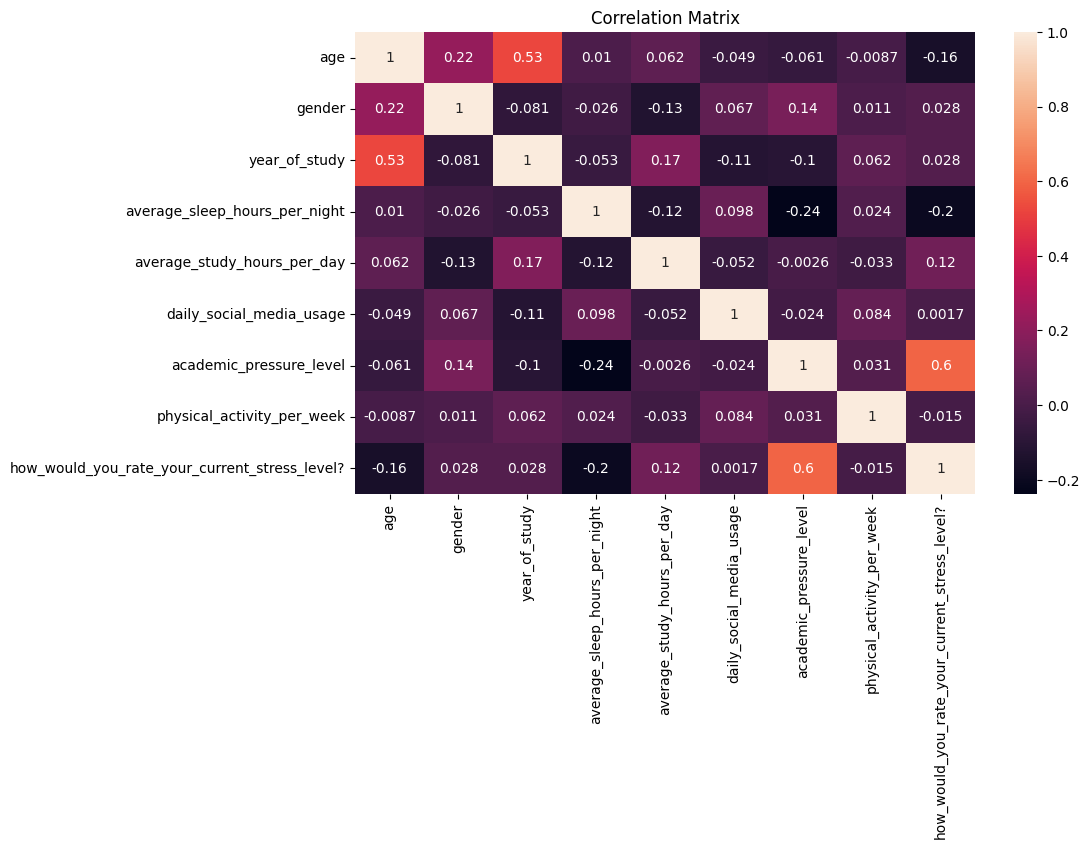

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

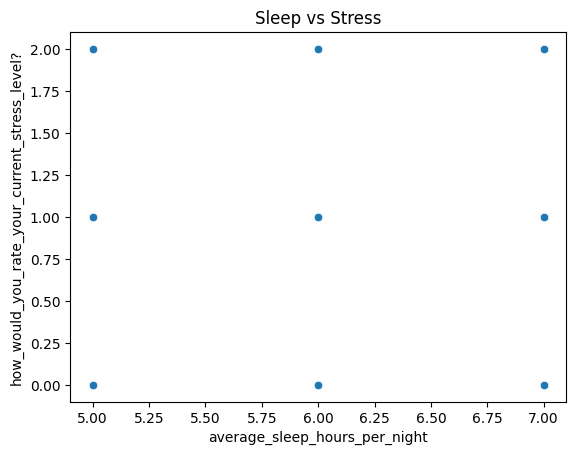

In [28]:
sns.scatterplot(x=df['average_sleep_hours_per_night'], y=df['how_would_you_rate_your_current_stress_level?'])
plt.title("Sleep vs Stress")
plt.show()

In [29]:
for col in df.columns:
    print(col)

age
gender
year_of_study
average_sleep_hours_per_night
average_study_hours_per_day
daily_social_media_usage
academic_pressure_level
physical_activity_per_week
how_would_you_rate_your_current_stress_level?


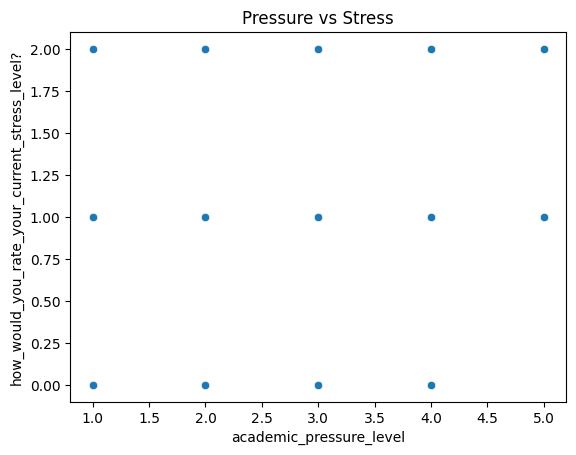

In [30]:
sns.scatterplot(x=df['academic_pressure_level'], y=df['how_would_you_rate_your_current_stress_level?'])
plt.title("Pressure vs Stress")
plt.show()

In [31]:
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(acc_lr, acc_dt, acc_rf)

0.6470588235294118 0.5 0.5588235294117647


In [32]:
results = results.sort_values(by="Accuracy", ascending=False)
print(results)

           Model  Accuracy
0       Logistic  0.647059
2  Random Forest  0.558824
1  Decision Tree  0.500000


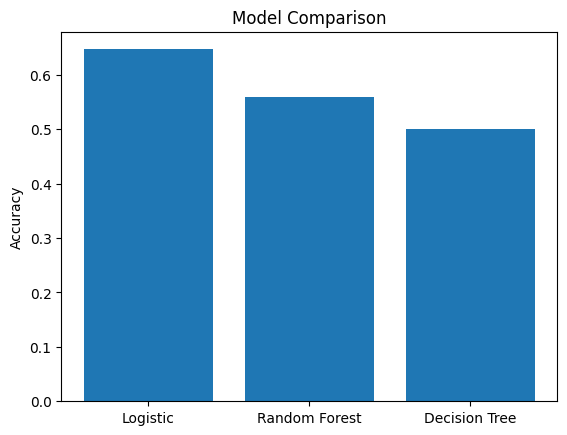

In [33]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

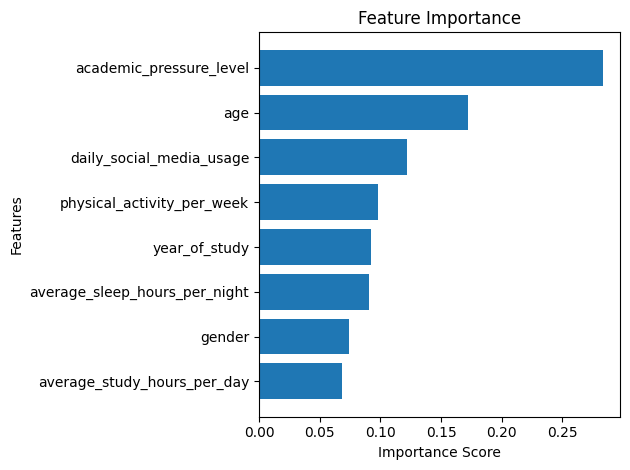

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Create dataframe
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort values
feat_imp = feat_imp.sort_values(by='Importance', ascending=True)

# Plot (horizontal bar = cleaner)
plt.figure()
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()  # VERY IMPORTANT (fixes cut labels)
plt.show()

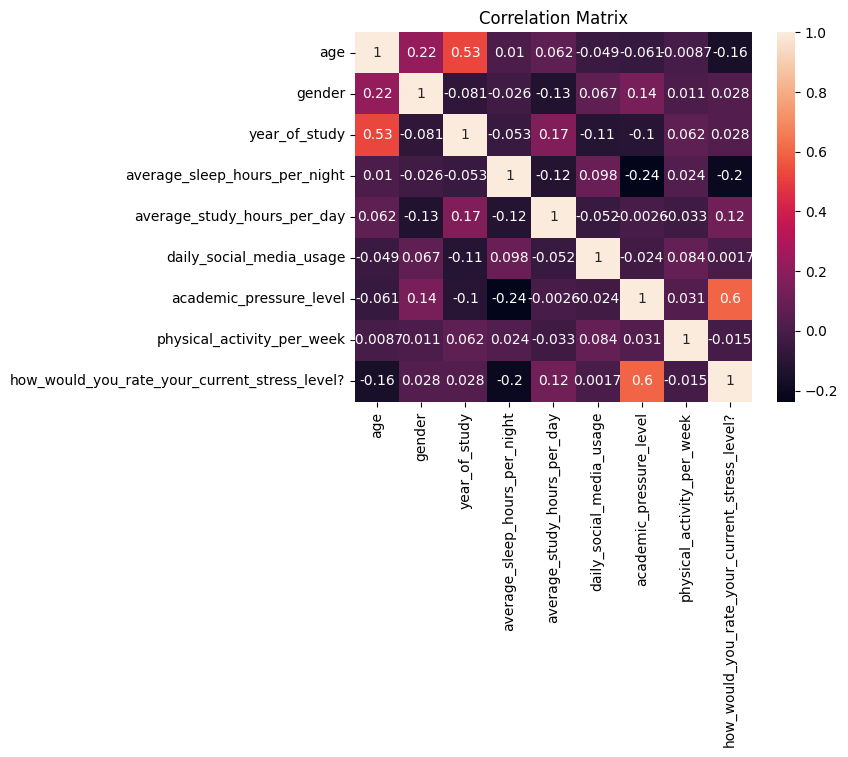

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

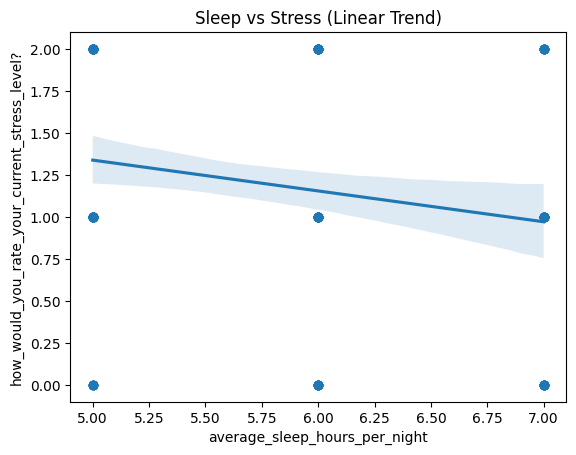

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x=df['average_sleep_hours_per_night'], 
            y=df['how_would_you_rate_your_current_stress_level?'])

plt.title("Sleep vs Stress (Linear Trend)")
plt.show()

In [37]:
df.corr(numeric_only=True)['how_would_you_rate_your_current_stress_level?'].sort_values(ascending=False)

how_would_you_rate_your_current_stress_level?    1.000000
academic_pressure_level                          0.596336
average_study_hours_per_day                      0.118434
gender                                           0.028156
year_of_study                                    0.028150
daily_social_media_usage                         0.001657
physical_activity_per_week                      -0.015405
age                                             -0.156651
average_sleep_hours_per_night                   -0.201941
Name: how_would_you_rate_your_current_stress_level?, dtype: float64

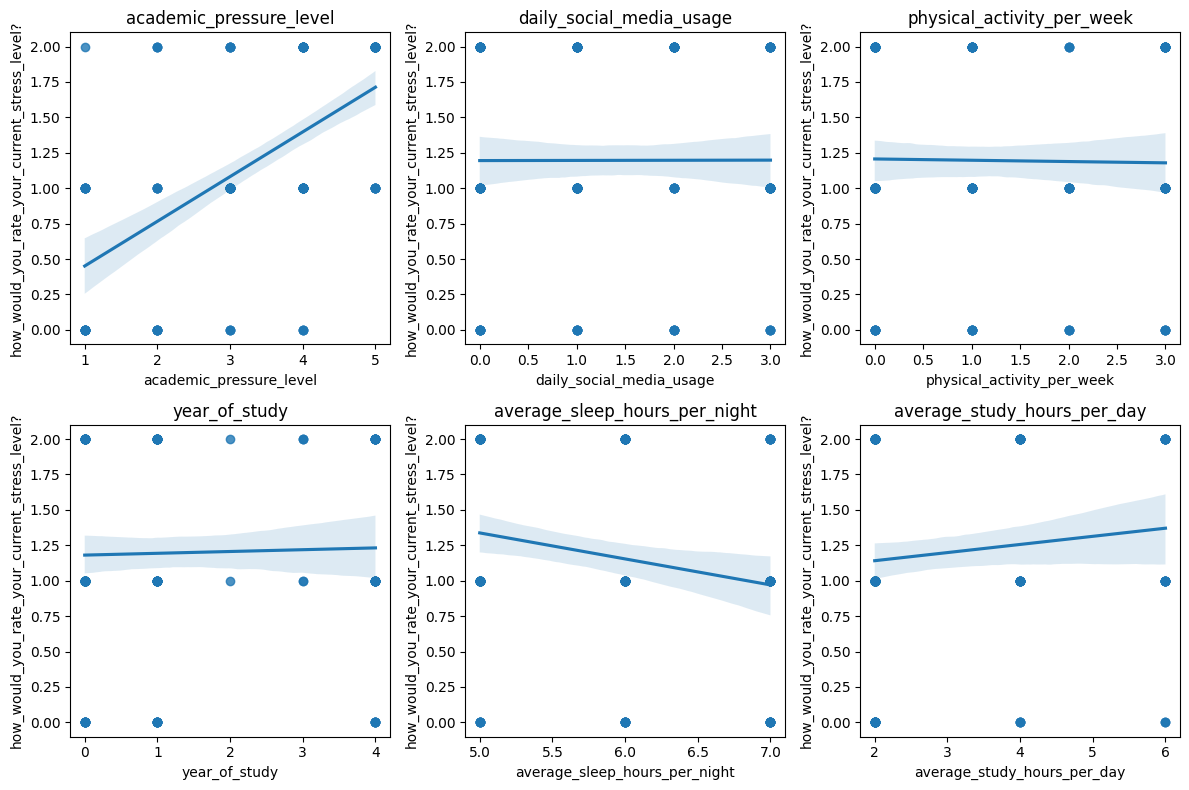

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select features (update names based on your dataset)
features = [
    'academic_pressure_level',
    'daily_social_media_usage',
    'physical_activity_per_week',
    'year_of_study',
    'average_sleep_hours_per_night',
    'average_study_hours_per_day'
]

target = 'how_would_you_rate_your_current_stress_level?'

# Create subplots
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.regplot(x=df[feature], y=df[target])
    plt.title(feature)

plt.tight_layout()
plt.show()

In [39]:
drop_cols = ['gender', 'age']

df_filtered = df.drop(columns=drop_cols, errors='ignore')

In [40]:
target = 'how_would_you_rate_your_current_stress_level?'

corr_values = df_filtered.corr(numeric_only=True)[target].sort_values(ascending=False)

print(corr_values)

how_would_you_rate_your_current_stress_level?    1.000000
academic_pressure_level                          0.596336
average_study_hours_per_day                      0.118434
year_of_study                                    0.028150
daily_social_media_usage                         0.001657
physical_activity_per_week                      -0.015405
average_sleep_hours_per_night                   -0.201941
Name: how_would_you_rate_your_current_stress_level?, dtype: float64


In [41]:
for feature, value in corr_values.items():
    if feature != target:
        if value > 0:
            print(f"{feature}: {value:.2f} →                                           Positive")
        elif value < 0:
            print(f"{feature}: {value:.2f} →                                           Negative")

academic_pressure_level: 0.60 →                                           Positive
average_study_hours_per_day: 0.12 →                                           Positive
year_of_study: 0.03 →                                           Positive
daily_social_media_usage: 0.00 →                                           Positive
physical_activity_per_week: -0.02 →                                           Negative
average_sleep_hours_per_night: -0.20 →                                           Negative


In [42]:
# Final Conclusion:
# Logistic Regression performed best among all models.
# This indicates that the dataset follows a mostly linear relationship.
# Academic pressure is the strongest factor affecting stress,
# while sleep shows a negative relationship.

In [43]:
# Example input (change values)
sample = [[
    3,   # academic_pressure
    2,   # daily_social_media_usage
    3,   # physical_activity_per_week
    6,   # average_sleep_hours_per_night
    4    # average_study_hours_per_day
]]

In [44]:
sample_scaled = scaler.transform(sample)

C:\Users\rabiy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 5 features, but StandardScaler is expecting 8 features as input.